In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

BASE_DIR = Path("..")
panel = pd.read_csv(BASE_DIR / "data/curated/master_panel.csv")
usd   = pd.read_csv(BASE_DIR / "data/staging/usd_dominance_clean.csv")
print(panel.shape, usd.shape)

(4283, 28) (25, 13)


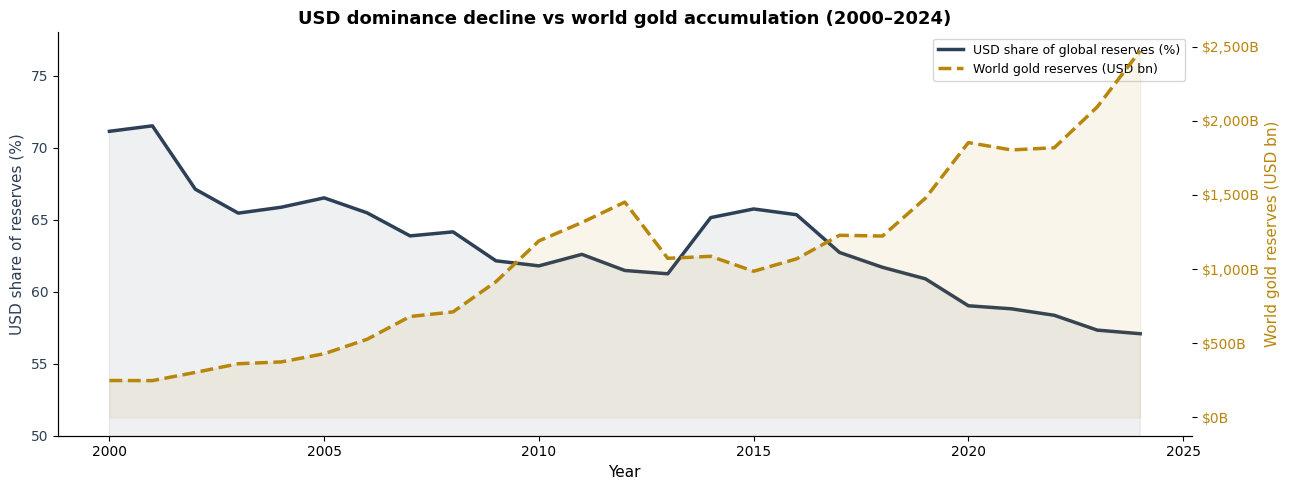

Saved: docs/usd_vs_gold_thesis.png


In [2]:
fig, ax1 = plt.subplots(figsize=(13, 5))

color_usd  = "#2E4057"
color_gold = "#B8860B"

ax1.plot(usd["year"], usd["usd_share_of_reserves_pct"],
         color=color_usd, linewidth=2.5, label="USD share of global reserves (%)")
ax1.fill_between(usd["year"], usd["usd_share_of_reserves_pct"],
                 alpha=0.08, color=color_usd)
ax1.set_ylabel("USD share of reserves (%)", color=color_usd, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_usd)
ax1.set_ylim(50, 78)

ax2 = ax1.twinx()
ax2.plot(usd["year"], usd["world_gold_value_bn"],
         color=color_gold, linewidth=2.5, linestyle="--", label="World gold reserves (USD bn)")
ax2.fill_between(usd["year"], usd["world_gold_value_bn"],
                 alpha=0.08, color=color_gold)
ax2.set_ylabel("World gold reserves (USD bn)", color=color_gold, fontsize=11)
ax2.tick_params(axis="y", labelcolor=color_gold)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}B"))

ax1.set_xlabel("Year", fontsize=11)
ax1.set_title("USD dominance decline vs world gold accumulation (2000–2024)",
              fontsize=13, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig(BASE_DIR / "docs/usd_vs_gold_thesis.png", dpi=150)
plt.show()
print("Saved: docs/usd_vs_gold_thesis.png")

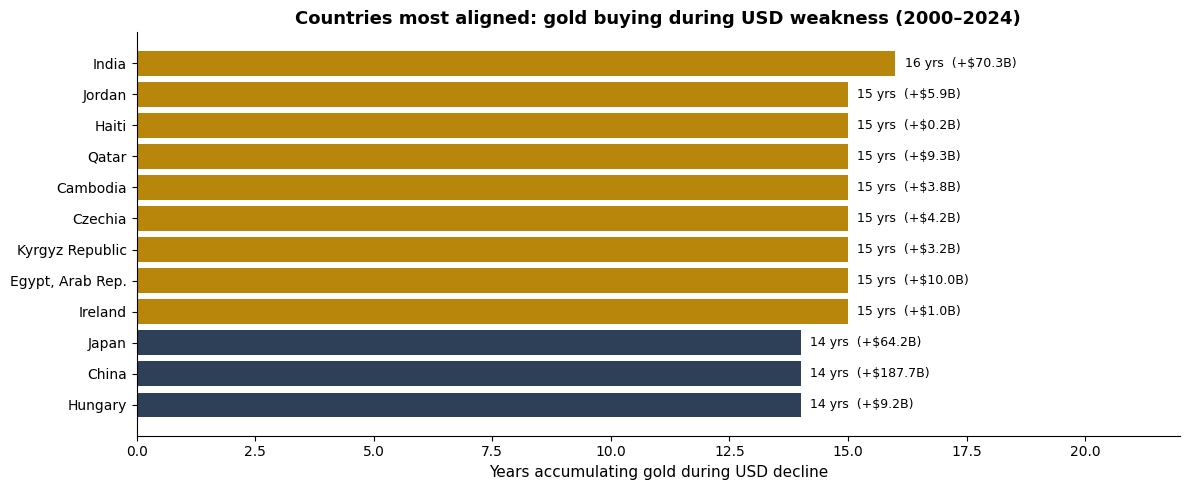

Saved: docs/accumulation_vs_usd_decline.png


In [3]:
summary = (
    panel.groupby(["country", "country_code"])
    .agg(
        years_aligned=("accumulating_during_usd_decline", "sum"),
        total_gold_added_bn=("gold_yoy_change_usd", lambda x: round(x.sum() / 1e9, 1)),
        latest_gold_share=("gold_share_pct", "last"),
    )
    .reset_index()
    .sort_values("years_aligned", ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(summary["country"], summary["years_aligned"],
               color=["#B8860B" if y >= 15 else "#2E4057" if y >= 12 else "#888780"
                      for y in summary["years_aligned"]])

ax.set_xlabel("Years accumulating gold during USD decline", fontsize=11)
ax.set_title("Countries most aligned: gold buying during USD weakness (2000–2024)",
             fontsize=13, fontweight="bold")
ax.invert_yaxis()

for i, (val, added) in enumerate(zip(summary["years_aligned"],
                                      summary["total_gold_added_bn"])):
    ax.text(val + 0.2, i, f"{val} yrs  (+${added}B)", va="center", fontsize=9)

ax.set_xlim(0, 22)
sns.despine()
plt.tight_layout()
plt.savefig(BASE_DIR / "docs/accumulation_vs_usd_decline.png", dpi=150)
plt.show()
print("Saved: docs/accumulation_vs_usd_decline.png")

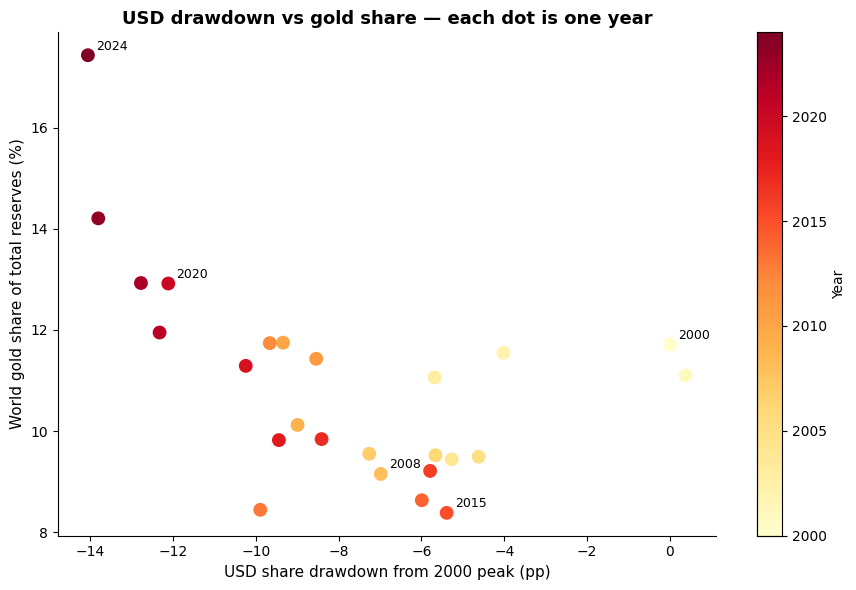

Saved: docs/usd_drawdown_vs_gold_share.png


In [4]:
yearly = usd[["year", "usd_share_drawdown_pct", "world_gold_share_pct"]].copy()

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(yearly["usd_share_drawdown_pct"], yearly["world_gold_share_pct"],
                c=yearly["year"], cmap="YlOrRd", s=80, zorder=3)

for _, row in yearly.iterrows():
    if row["year"] in [2000, 2008, 2015, 2020, 2024]:
        ax.annotate(str(int(row["year"])),
                    (row["usd_share_drawdown_pct"], row["world_gold_share_pct"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)

plt.colorbar(sc, label="Year")
ax.set_xlabel("USD share drawdown from 2000 peak (pp)", fontsize=11)
ax.set_ylabel("World gold share of total reserves (%)", fontsize=11)
ax.set_title("USD drawdown vs gold share — each dot is one year",
             fontsize=13, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.savefig(BASE_DIR / "docs/usd_drawdown_vs_gold_share.png", dpi=150)
plt.show()
print("Saved: docs/usd_drawdown_vs_gold_share.png")
